In [ ]:
import torch
import pandas as pd
import numpy as np
from math import factorial
import time
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using compute device: {device}")


Using compute device: cpu


In [ ]:
def GenerateGaussLaguerre(n):
    """Generates Gauss-Laguerre nodes and weights using numpy, then moves to GPU"""
    def nchoosek(n, r):
        return factorial(n) / (factorial(r) * factorial(n - r))

    x, _ = np.polynomial.laguerre.laggauss(n)
    w = np.zeros(n)
    dL = np.zeros((n, len(x)))
    for j in range(len(x)):
        for k in range(n):
            dL[k, j] = (-1)**(k+1) / factorial(k) * nchoosek(n, k+1) * x[j]**(k)
        w[j] = 1 / x[j] / sum(dL[:, j])**2
        w[j] = w[j] * np.exp(x[j])

    return torch.tensor(x, dtype=torch.float64, device=device).unsqueeze(0), \
           torch.tensor(w, dtype=torch.float64, device=device).unsqueeze(0)

In [ ]:
def JumpCF_PT(phi, lambdJ, muJ, sigmaJ, T):
    i = 1j
    term1 = -lambdJ * muJ * i * phi * T
    term2 = lambdJ * T * ((1 + muJ)**(i * phi) * torch.exp(0.5 * sigmaJ**2 * i * phi * (i * phi - 1)) - 1)
    return torch.exp(term1 + term2)

def HestonCF_PT(phi, kappa, theta, sigma, v0, rho, T, S, r, q):
    i = 1j
    lambd = 1e-20
    x = torch.log(S)
    a = kappa * theta
    u = -0.5
    b = kappa + lambd

    # Protect against nan/inf in sqrt
    inside_sqrt = (rho * sigma * i * phi - b)**2 - sigma**2 * (2 * u * i * phi - phi**2)
    d = torch.sqrt(inside_sqrt)

    # FIX: Calculate 'c' directly instead of computing 'g' and inverting it.
    # This prevents complex division-by-zero when phi = -i
    c = (b - rho * sigma * i * phi - d) / (b - rho * sigma * i * phi + d)

    # "Little Trap" formulation
    exp_dT = torch.exp(-d * T)
    D = (b - rho * sigma * i * phi - d) / sigma**2 * ((1 - exp_dT) / (1 - c * exp_dT))
    G = (1 - c * exp_dT) / (1 - c)
    C = (r - q) * i * phi * T + a / sigma**2 * ((b - rho * sigma * i * phi - d) * T - 2 * torch.log(G))

    return torch.exp(C + D * v0 + i * phi * x)

def BatesCF_PT(phi, kappa, theta, sigma, v0, rho, lambdJ, muJ, sigmaJ, T, S, r, q):
    h_cf = HestonCF_PT(phi, kappa, theta, sigma, v0, rho, T, S, r, q)
    j_cf = JumpCF_PT(phi, lambdJ, muJ, sigmaJ, T)
    return h_cf * j_cf


In [ ]:
def SVprice_Batched(kappa, theta, sigma, v0, rho, lambdJ, muJ, sigmaJ, T, K, S, r, q, x_nodes, w_nodes):
    """Batched Pricing for Bates (with Jumps)"""
    i = 1j

    # Ensure phi (integration nodes) is complex for CF evaluation
    phi = x_nodes + 0.0j

    # Calculate integrand for P2
    f2 = BatesCF_PT(phi, kappa, theta, sigma, v0, rho, lambdJ, muJ, sigmaJ, T, S, r, q)
    int2 = (torch.exp(-i * phi * torch.log(K)) * f2 / (i * phi)).real

    # Calculate integrand for P1
    phi_minus_i = phi - i
    f1_num = BatesCF_PT(phi_minus_i, kappa, theta, sigma, v0, rho, lambdJ, muJ, sigmaJ, T, S, r, q)

    # Denominator evaluated at phi = -i (scalar broadcasted)
    phi_den = torch.tensor(-1j, dtype=torch.complex128, device=device)
    f1_den = BatesCF_PT(phi_den, kappa, theta, sigma, v0, rho, lambdJ, muJ, sigmaJ, T, S, r, q)

    int1 = (torch.exp(-i * phi * torch.log(K)) * f1_num / (i * phi * f1_den)).real

    # Integrate using Gauss-Laguerre by taking the dot product with weights along the nodes dimension (dim=1)
    I1 = torch.sum(w_nodes * int1, dim=1)
    I2 = torch.sum(w_nodes * int2, dim=1)

    P1 = 0.5 + (1 / torch.pi) * I1
    P2 = 0.5 + (1 / torch.pi) * I2

    CallPrice = S * torch.exp(-q * T) * P1 - K * torch.exp(-r * T) * P2

    # Mask out deeply negative prices caused by numerical instability in extreme params
    return torch.clamp(CallPrice, min=1e-7)


In [ ]:
def SVprice_Heston_Batched(kappa, theta, sigma, v0, rho, T, K, S, r, q, x_nodes, w_nodes):
    """Batched Pricing for Heston (No Jumps)"""
    i = 1j
    phi = x_nodes + 0.0j

    # Evaluate Heston CF directly
    f2 = HestonCF_PT(phi, kappa, theta, sigma, v0, rho, T, S, r, q)
    int2 = (torch.exp(-i * phi * torch.log(K)) * f2 / (i * phi)).real

    phi_minus_i = phi - i
    f1_num = HestonCF_PT(phi_minus_i, kappa, theta, sigma, v0, rho, T, S, r, q)
    phi_den = torch.tensor(-1j, dtype=torch.complex128, device=device)
    f1_den = HestonCF_PT(phi_den, kappa, theta, sigma, v0, rho, T, S, r, q)

    int1 = (torch.exp(-i * phi * torch.log(K)) * f1_num / (i * phi * f1_den)).real

    I1 = torch.sum(w_nodes * int1, dim=1)
    I2 = torch.sum(w_nodes * int2, dim=1)

    P1 = 0.5 + (1 / torch.pi) * I1
    P2 = 0.5 + (1 / torch.pi) * I2

    CallPrice = S * torch.exp(-q * T) * P1 - K * torch.exp(-r * T) * P2
    return torch.clamp(CallPrice, min=1e-7)

In [ ]:
def bs_call_pt(S, K, T, r, q, vol):
    """Batched Black-Scholes Call formulation"""
    d1 = (torch.log(S/K) + (r - q + 0.5 * vol**2) * T) / (vol * torch.sqrt(T))
    d2 = d1 - vol * torch.sqrt(T)
    norm_dist = torch.distributions.Normal(0, 1)
    return S * torch.exp(-q * T) * norm_dist.cdf(d1) - K * torch.exp(-r * T) * norm_dist.cdf(d2)

def implied_vol_batched(target_prices, S, K, T, r, q, max_iter=40):
    """Finds IV for thousands of prices simultaneously using Bisection on GPU"""
    low = torch.full_like(target_prices, 1e-4)
    high = torch.full_like(target_prices, 5.0) # Search up to 500% IV

    for _ in range(max_iter):
        mid = (low + high) / 2.0
        prices_mid = bs_call_pt(S, K, T, r, q, mid)

        # Where estimated price > target, IV is too high. Where price <= target, IV is too low.
        high = torch.where(prices_mid > target_prices, mid, high)
        low = torch.where(prices_mid <= target_prices, mid, low)

    return (low + high) / 2.0

In [ ]:
def Bergomi_1F_MC_Batched(xi, nu, rho, beta, T, K_strikes, S, r, q, N_paths=10000, N_steps=50):
    """
    Batched Monte Carlo for 1-Factor Bergomi.
    Correctly aligns 2D and 3D tensors for PyTorch broadcasting.
    """
    with torch.no_grad():
        dt = T / N_steps
        num_samples = xi.shape[0]

        # 2D Parameters for the (Batch, N_paths) operations
        xi = xi.view(-1, 1)
        nu = nu.view(-1, 1)
        beta = beta.view(-1, 1)

        # 3D Parameter for the (Batch, N_paths, N_steps) operations
        rho = rho.view(-1, 1, 1)

        Z1 = torch.randn(num_samples, N_paths, N_steps, dtype=torch.float64, device=device)
        Z2 = torch.randn(num_samples, N_paths, N_steps, dtype=torch.float64, device=device)
        dW_S = Z1 * math.sqrt(dt)

        # rho is (Batch, 1, 1) safely broadcasting against Z1 (Batch, N_paths, N_steps)
        dW_V = (rho * Z1 + torch.sqrt(1 - rho**2) * Z2) * math.sqrt(dt)

        X = torch.zeros(num_samples, N_paths, dtype=torch.float64, device=device)
        log_S = torch.log(torch.tensor(S, dtype=torch.float64, device=device)).expand(num_samples, N_paths).clone()

        for t in range(N_steps):
            t_val = (t + 1) * dt

            # Deterministic variance of OU
            E_X2 = (1 - torch.exp(-2 * beta * t_val)) / (2 * beta)

            # Cleanly broadcasts (B, 1) against (B, N_paths)
            V_t = xi * torch.exp(nu * X - 0.5 * nu**2 * E_X2)

            # Euler step for Log Spot
            log_S = log_S + (r - q - 0.5 * V_t) * dt + torch.sqrt(V_t) * dW_S[:, :, t]

            # Euler step for OU Variance process
            X = X - beta * X * dt + dW_V[:, :, t]

        S_T = torch.exp(log_S)

        # Calculate payoff for all strikes simultaneously
        K_tensor = torch.tensor(K_strikes, dtype=torch.float64, device=device).view(1, 1, -1)
        payoffs = torch.relu(S_T.unsqueeze(-1) - K_tensor)

        CallPrices = torch.mean(payoffs, dim=1) * math.exp(-r * T)
        return torch.clamp(CallPrices, min=1e-7)

def rBergomi_MC_Batched(xi, nu, rho, H, T, K_strikes, S, r, q, N_paths=10000, N_steps=50):
    """
    Batched Monte Carlo for Rough Bergomi using Riemann-Sum Volterra approximation.
    """
    dt = T / N_steps
    num_samples = xi.shape[0]

    xi = xi.view(-1, 1, 1)
    nu = nu.view(-1, 1, 1)
    rho = rho.view(-1, 1, 1)
    H = H.view(-1, 1, 1)

    Z1 = torch.randn(num_samples, N_paths, N_steps, dtype=torch.float64, device=device)
    Z2 = torch.randn(num_samples, N_paths, N_steps, dtype=torch.float64, device=device)
    dW_S = Z1 * math.sqrt(dt)
    dW_V = (rho * Z1 + torch.sqrt(1 - rho**2) * Z2) * math.sqrt(dt)

    log_S = torch.log(torch.tensor(S, dtype=torch.float64, device=device)).expand(num_samples, N_paths)

    # Riemann Sum Volterra Convolution (highly optimized for GPU)
    for t in range(N_steps):
        t_val = (t + 1) * dt
        if t == 0:
            Z_t = torch.zeros_like(log_S)
        else:
            # Create time kernel (t - s)^(H - 0.5)
            s_vals = torch.arange(0, t, device=device, dtype=torch.float64) * dt
            kernel = (t_val - s_vals).view(1, 1, -1) ** (H - 0.5)
            # Dot product of kernel and historical dW_V
            Z_t = torch.sum(kernel * dW_V[:, :, :t], dim=2)

        # Rough Bergomi Variance
        V_t = xi * torch.exp(nu * math.sqrt(2) * torch.sqrt(H) * Z_t.unsqueeze(-1) - 0.5 * nu**2 * (t_val ** (2 * H)))

        # Spot Euler Step
        log_S = log_S + (r - q - 0.5 * V_t.squeeze(-1)) * dt + torch.sqrt(V_t.squeeze(-1)) * dW_S[:, :, t]

    S_T = torch.exp(log_S)

    K_tensor = torch.tensor(K_strikes, dtype=torch.float64, device=device).view(1, 1, -1)
    payoffs = torch.relu(S_T.unsqueeze(-1) - K_tensor)

    CallPrices = torch.mean(payoffs, dim=1) * math.exp(-r * T)
    return torch.clamp(CallPrices, min=1e-7)

In [ ]:
def Sentiment_OU_Step(Y_t, Z_Y, dt, kappa_Y, theta_Y, sigma_Y, lambd_Y, mu_JY, sigma_JY, device):
    jump_mask = (torch.rand_like(Y_t) < (lambd_Y * dt)).double()
    jump_sizes = (torch.randn_like(Y_t) * sigma_JY + mu_JY) * jump_mask
    dY = kappa_Y * (theta_Y - Y_t) * dt + sigma_Y * math.sqrt(dt) * Z_Y + jump_sizes
    return Y_t + dY

def Sentiment_Heston_Bates_MC_Batched(model_type, kappa, theta, sigma, v0, rho_SV, rho_SY,
                                      kappa_Y, theta_Y, sigma_Y, lambd_Y, mu_JY, sigma_JY, beta_S, beta_V,
                                      lambdJ, muJ, sigmaJ, T, K_strikes, S, r, q, N_paths=10000, N_steps=50, device='cpu'):
    with torch.no_grad():
        dt = T / N_steps
        num_samples = kappa.shape[0]

        kappa, theta, sigma, v0 = kappa.view(-1, 1), theta.view(-1, 1), sigma.view(-1, 1), v0.view(-1, 1)
        rho_SV, rho_SY = rho_SV.view(-1, 1), rho_SY.view(-1, 1)
        kappa_Y, theta_Y, sigma_Y = kappa_Y.view(-1, 1), theta_Y.view(-1, 1), sigma_Y.view(-1, 1)
        lambd_Y, mu_JY, sigma_JY = lambd_Y.view(-1, 1), mu_JY.view(-1, 1), sigma_JY.view(-1, 1)
        beta_S, beta_V = beta_S.view(-1, 1), beta_V.view(-1, 1)

        if model_type == 'Bates':
            lambdJ, muJ, sigmaJ = lambdJ.view(-1, 1), muJ.view(-1, 1), sigmaJ.view(-1, 1)

        Z1 = torch.randn(num_samples, N_paths, N_steps, dtype=torch.float64, device=device)
        Z2 = torch.randn(num_samples, N_paths, N_steps, dtype=torch.float64, device=device)
        Z3 = torch.randn(num_samples, N_paths, N_steps, dtype=torch.float64, device=device)

        Z_S = Z1
        Z_V = rho_SV.unsqueeze(-1) * Z1 + torch.sqrt(1 - rho_SV**2).unsqueeze(-1) * Z2
        Z_Y = rho_SY.unsqueeze(-1) * Z1 + torch.sqrt(1 - rho_SY**2).unsqueeze(-1) * Z3

        V_t = v0.expand(num_samples, N_paths).clone()
        Y_t = theta_Y.expand(num_samples, N_paths).clone()
        log_S = torch.log(torch.tensor(S, dtype=torch.float64, device=device)).expand(num_samples, N_paths).clone()

        log_S_history = torch.zeros((num_samples, N_paths, N_steps + 1), dtype=torch.float64, device=device)
        log_S_history[:, :, 0] = log_S

        for t in range(N_steps):
            Y_t = Sentiment_OU_Step(Y_t, Z_Y[:, :, t], dt, kappa_Y, theta_Y, sigma_Y, lambd_Y, mu_JY, sigma_JY, device)

            if model_type == 'Bates':
                S_jump_mask = (torch.rand_like(log_S) < (lambdJ * dt)).double()
                S_jump_sizes = (torch.randn_like(log_S) * sigmaJ + muJ) * S_jump_mask
            else:
                S_jump_sizes = 0.0

            V_next = V_t + kappa * (theta * torch.exp(beta_V * Y_t) - V_t) * dt + sigma * torch.sqrt(torch.clamp(V_t, min=0.0)) * math.sqrt(dt) * Z_V[:, :, t]
            V_t = torch.clamp(V_next, min=1e-8)

            log_S = log_S + (r - q - 0.5 * V_t + beta_S * Y_t) * dt + torch.sqrt(V_t) * math.sqrt(dt) * Z_S[:, :, t] + S_jump_sizes
            log_S_history[:, :, t + 1] = log_S

        S_T = torch.exp(log_S)
        K_tensor = torch.tensor(K_strikes, dtype=torch.float64, device=device).view(1, 1, -1)
        payoffs = torch.relu(S_T.unsqueeze(-1) - K_tensor)
        CallPrices = torch.clamp(torch.mean(payoffs, dim=1) * math.exp(-r * T), min=1e-7)

        return CallPrices, log_S_history

def Sentiment_Bergomi_MC_Batched(xi, nu, rho_SV, rho_SY, beta,
                                 kappa_Y, theta_Y, sigma_Y, lambd_Y, mu_JY, sigma_JY, beta_S, beta_V,
                                 T, K_strikes, S, r, q, N_paths=10000, N_steps=50, device='cpu'):
    with torch.no_grad():
        dt = T / N_steps
        num_samples = xi.shape[0]

        xi, nu = xi.view(-1, 1), nu.view(-1, 1)
        rho_SV, rho_SY = rho_SV.view(-1, 1), rho_SY.view(-1, 1)
        beta = beta.view(-1, 1)
        kappa_Y, theta_Y, sigma_Y = kappa_Y.view(-1, 1), theta_Y.view(-1, 1), sigma_Y.view(-1, 1)
        lambd_Y, mu_JY, sigma_JY = lambd_Y.view(-1, 1), mu_JY.view(-1, 1), sigma_JY.view(-1, 1)
        beta_S, beta_V = beta_S.view(-1, 1), beta_V.view(-1, 1)

        Z1 = torch.randn(num_samples, N_paths, N_steps, dtype=torch.float64, device=device)
        Z2 = torch.randn(num_samples, N_paths, N_steps, dtype=torch.float64, device=device)
        Z3 = torch.randn(num_samples, N_paths, N_steps, dtype=torch.float64, device=device)

        rho_SV_exp = rho_SV.unsqueeze(-1)
        rho_SY_exp = rho_SY.unsqueeze(-1)

        dW_S = Z1 * math.sqrt(dt)
        dW_V = (rho_SV_exp * Z1 + torch.sqrt(1 - rho_SV_exp**2) * Z2) * math.sqrt(dt)
        Z_Y = rho_SY_exp * Z1 + torch.sqrt(1 - rho_SY_exp**2) * Z3

        X = torch.zeros(num_samples, N_paths, dtype=torch.float64, device=device)
        Y_t = theta_Y.expand(num_samples, N_paths).clone()
        log_S = torch.log(torch.tensor(S, dtype=torch.float64, device=device)).expand(num_samples, N_paths).clone()

        log_S_history = torch.zeros((num_samples, N_paths, N_steps + 1), dtype=torch.float64, device=device)
        log_S_history[:, :, 0] = log_S

        for t in range(N_steps):
            t_val = (t + 1) * dt
            Y_t = Sentiment_OU_Step(Y_t, Z_Y[:, :, t], dt, kappa_Y, theta_Y, sigma_Y, lambd_Y, mu_JY, sigma_JY, device)

            E_X2 = (1 - torch.exp(-2 * beta * t_val)) / (2 * beta)
            V_t = xi * torch.exp(nu * X - 0.5 * nu**2 * E_X2) * torch.exp(beta_V * Y_t)
            log_S = log_S + (r - q - 0.5 * V_t + beta_S * Y_t) * dt + torch.sqrt(V_t) * dW_S[:, :, t]
            X = X - beta * X * dt + dW_V[:, :, t]

            log_S_history[:, :, t + 1] = log_S

        S_T = torch.exp(log_S)
        K_tensor = torch.tensor(K_strikes, dtype=torch.float64, device=device).view(1, 1, -1)
        payoffs = torch.relu(S_T.unsqueeze(-1) - K_tensor)
        CallPrices = torch.clamp(torch.mean(payoffs, dim=1) * math.exp(-r * T), min=1e-7)

        return CallPrices, log_S_history

def Sentiment_rBergomi_MC_Batched(xi, nu, rho_SV, rho_SY, H,
                                  kappa_Y, theta_Y, sigma_Y, lambd_Y, mu_JY, sigma_JY, beta_S, beta_V,
                                  T, K_strikes, S, r, q, N_paths=10000, N_steps=50, device='cpu'):
    with torch.no_grad():
        dt = T / N_steps
        num_samples = xi.shape[0]

        xi, nu = xi.view(-1, 1), nu.view(-1, 1)
        rho_SV, rho_SY = rho_SV.view(-1, 1), rho_SY.view(-1, 1)
        H = H.view(-1, 1)
        kappa_Y, theta_Y, sigma_Y = kappa_Y.view(-1, 1), theta_Y.view(-1, 1), sigma_Y.view(-1, 1)
        lambd_Y, mu_JY, sigma_JY = lambd_Y.view(-1, 1), mu_JY.view(-1, 1), sigma_JY.view(-1, 1)
        beta_S, beta_V = beta_S.view(-1, 1), beta_V.view(-1, 1)

        Z1 = torch.randn(num_samples, N_paths, N_steps, dtype=torch.float64, device=device)
        Z2 = torch.randn(num_samples, N_paths, N_steps, dtype=torch.float64, device=device)
        Z3 = torch.randn(num_samples, N_paths, N_steps, dtype=torch.float64, device=device)

        rho_SV_exp = rho_SV.unsqueeze(-1)
        rho_SY_exp = rho_SY.unsqueeze(-1)

        dW_S = Z1 * math.sqrt(dt)
        dW_V = (rho_SV_exp * Z1 + torch.sqrt(1 - rho_SV_exp**2) * Z2) * math.sqrt(dt)
        Z_Y = rho_SY_exp * Z1 + torch.sqrt(1 - rho_SY_exp**2) * Z3

        Y_t = theta_Y.expand(num_samples, N_paths).clone()
        log_S = torch.log(torch.tensor(S, dtype=torch.float64, device=device)).expand(num_samples, N_paths).clone()

        log_S_history = torch.zeros((num_samples, N_paths, N_steps + 1), dtype=torch.float64, device=device)
        log_S_history[:, :, 0] = log_S

        for t in range(N_steps):
            t_val = (t + 1) * dt
            Y_t = Sentiment_OU_Step(Y_t, Z_Y[:, :, t], dt, kappa_Y, theta_Y, sigma_Y, lambd_Y, mu_JY, sigma_JY, device)

            if t == 0:
                Z_t = torch.zeros_like(log_S)
            else:
                s_vals = torch.arange(0, t, device=device, dtype=torch.float64) * dt
                kernel = (t_val - s_vals).view(1, 1, -1) ** (H.unsqueeze(-1) - 0.5)
                Z_t = torch.sum(kernel * dW_V[:, :, :t], dim=2)

            V_t = xi * torch.exp(nu * math.sqrt(2) * torch.sqrt(H) * Z_t - 0.5 * nu**2 * (t_val ** (2 * H)))
            V_t = V_t * torch.exp(beta_V * Y_t)
            log_S = log_S + (r - q - 0.5 * V_t + beta_S * Y_t) * dt + torch.sqrt(V_t) * dW_S[:, :, t]

            log_S_history[:, :, t + 1] = log_S

        S_T = torch.exp(log_S)
        K_tensor = torch.tensor(K_strikes, dtype=torch.float64, device=device).view(1, 1, -1)
        payoffs = torch.relu(S_T.unsqueeze(-1) - K_tensor)

        CallPrices = torch.clamp(torch.mean(payoffs, dim=1) * math.exp(-r * T), min=1e-7)
        return CallPrices, log_S_history

In [ ]:
import torch
import math
import matplotlib.pyplot as plt
import numpy as np

# Change to 'cuda' if running on a GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Simulation Parameters
T = 1.0          # Time to Maturity (Years)
N_steps = 250    # Number of time steps (roughly daily)
N_paths = 500      # Number of paths to plot
dt = T / N_steps

# Common Model Parameters
xi = 0.04
nu = 2.5
rho = -0.7
S0 = 1.0
r = 0.0
q = 0.0

# Bergomi params
beta = 1.5

# rBergomi params
H = 0.05

# Generate standard normal increments
torch.manual_seed(42)
Z1 = torch.randn(N_paths, N_steps, dtype=torch.float64, device=device)
Z2 = torch.randn(N_paths, N_steps, dtype=torch.float64, device=device)

# Correlate Brownian Motions for Spot and Variance
dW_S = Z1 * math.sqrt(dt)
dW_V = (rho * Z1 + math.sqrt(1 - rho**2) * Z2) * math.sqrt(dt)

# ============================================
# 1-Factor Bergomi Simulation
# ============================================
X = torch.zeros(N_paths, dtype=torch.float64, device=device)
log_S_bergomi = torch.log(torch.tensor(S0, dtype=torch.float64, device=device)).expand(N_paths).clone()

V_bergomi_paths = torch.zeros(N_paths, N_steps + 1, device=device)
S_bergomi_paths = torch.zeros(N_paths, N_steps + 1, device=device)
V_bergomi_paths[:, 0] = xi
S_bergomi_paths[:, 0] = S0

for t in range(N_steps):
    t_val = (t + 1) * dt
    # Deterministic expectation of the OU process squared
    E_X2 = (1 - math.exp(-2 * beta * t_val)) / (2 * beta)

    # 1F Bergomi Variance
    V_t = xi * torch.exp(nu * X - 0.5 * nu**2 * E_X2)
    V_bergomi_paths[:, t+1] = V_t

    # Spot Euler Step
    log_S_bergomi = log_S_bergomi + (r - q - 0.5 * V_t) * dt + torch.sqrt(V_t) * dW_S[:, t]
    S_bergomi_paths[:, t+1] = torch.exp(log_S_bergomi)

    # Variance OU Process Euler Step
    X = X - beta * X * dt + dW_V[:, t]

# ============================================
# Rough Bergomi (rBergomi) Simulation
# ============================================
log_S_rbergomi = torch.log(torch.tensor(S0, dtype=torch.float64, device=device)).expand(N_paths).clone()

V_rbergomi_paths = torch.zeros(N_paths, N_steps + 1, device=device)
S_rbergomi_paths = torch.zeros(N_paths, N_steps + 1, device=device)
V_rbergomi_paths[:, 0] = xi
S_rbergomi_paths[:, 0] = S0

for t in range(N_steps):
    t_val = (t + 1) * dt
    if t == 0:
        Z_t = torch.zeros(N_paths, dtype=torch.float64, device=device)
    else:
        # Volterra Kernel (Riemann Sum approximation)
        s_vals = torch.arange(0, t, device=device, dtype=torch.float64) * dt
        kernel = (t_val - s_vals) ** (H - 0.5)
        Z_t = torch.sum(kernel.unsqueeze(0) * dW_V[:, :t], dim=1)

    # rBergomi Variance
    V_t = xi * torch.exp(nu * math.sqrt(2 * H) * Z_t - 0.5 * nu**2 * (t_val ** (2 * H)))
    V_rbergomi_paths[:, t+1] = V_t

    # Spot Euler Step
    log_S_rbergomi = log_S_rbergomi + (r - q - 0.5 * V_t) * dt + torch.sqrt(V_t) * dW_S[:, t]
    S_rbergomi_paths[:, t+1] = torch.exp(log_S_rbergomi)



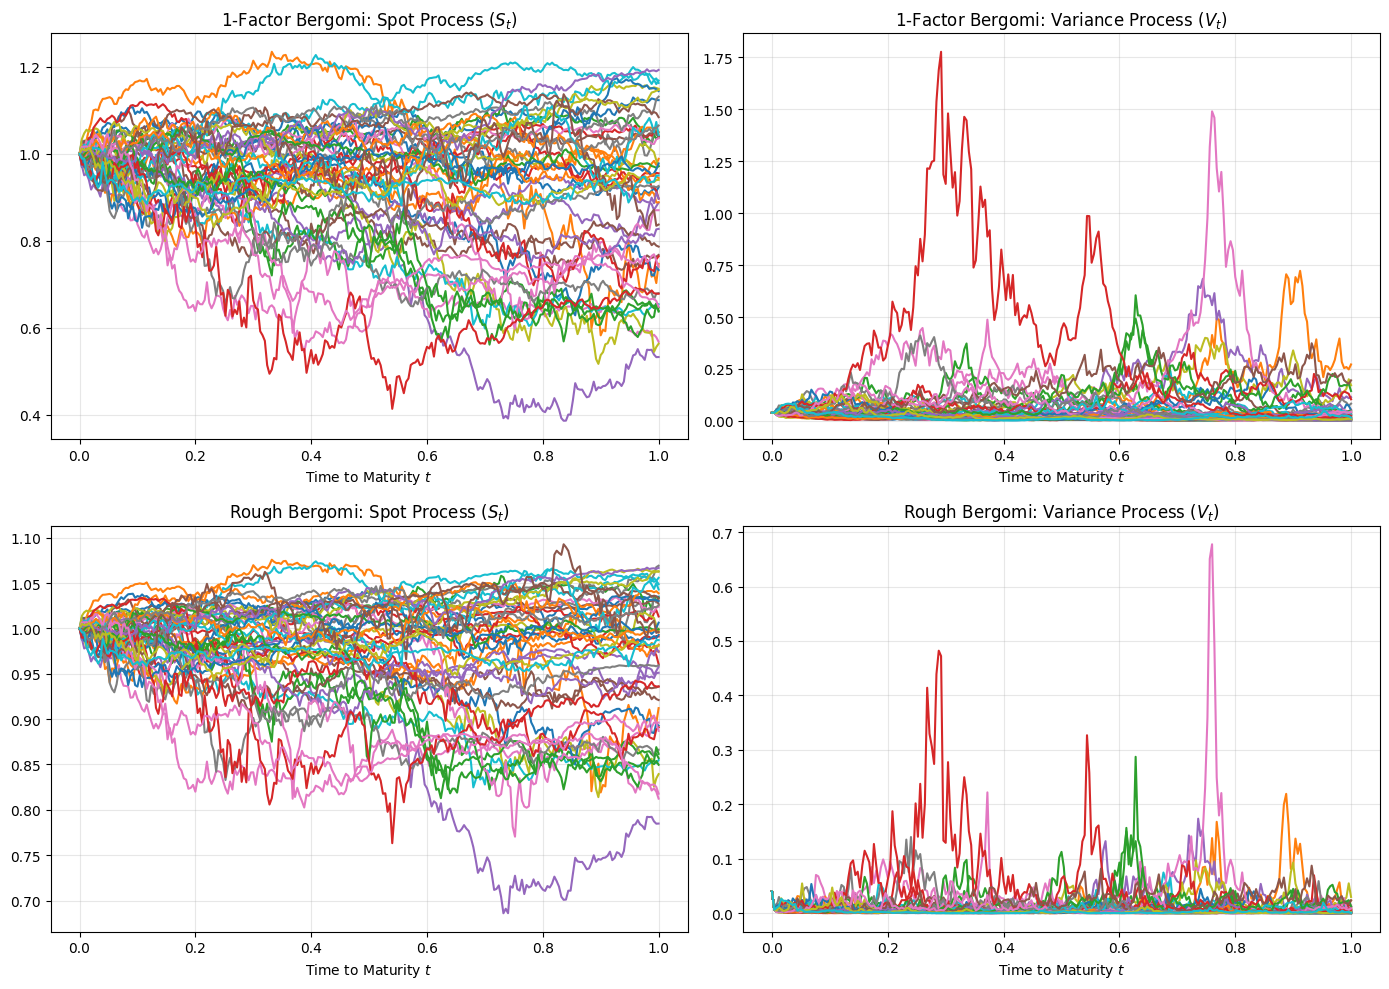

In [ ]:
# ============================================
# Plot the trajectories
# ============================================
time_grid = np.linspace(0, T, N_steps + 1)
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
n=1
for i in range(int(n*N_paths/10),int((n+1)*N_paths/10)):
    axs[0, 0].plot(time_grid, S_bergomi_paths[i].cpu().numpy(), lw=1.5)
    axs[0, 1].plot(time_grid, V_bergomi_paths[i].cpu().numpy(), lw=1.5)
    axs[1, 0].plot(time_grid, S_rbergomi_paths[i].cpu().numpy(), lw=1.5)
    axs[1, 1].plot(time_grid, V_rbergomi_paths[i].cpu().numpy(), lw=1.5)

axs[0, 0].set_title('1-Factor Bergomi: Spot Process ($S_t$)')
axs[0, 1].set_title('1-Factor Bergomi: Variance Process ($V_t$)')
axs[1, 0].set_title('Rough Bergomi: Spot Process ($S_t$)')
axs[1, 1].set_title('Rough Bergomi: Variance Process ($V_t$)')

for ax in axs.flat:
    ax.set_xlabel('Time to Maturity $t$')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import torch
import math

def compute_synthetic_sentiment(log_S_paths, T_val):
    """
    Translates Monte Carlo price/volatility paths into a synthetic sentiment
    score between -1 and 1, acting as a proxy for FinBERT news analysis.
    """
    with torch.no_grad():
        log_returns = log_S_paths[:, :, 1:] - log_S_paths[:, :, :-1]

        dt_sim = T_val / (log_S_paths.shape[2] - 1)
        dt_day = 1.0 / 252.0
        scale_mean = dt_day / dt_sim
        scale_vol = math.sqrt(dt_day / dt_sim)

        max_steps = log_returns.shape[2]
        steps_1d  = max(1, min(max_steps, int(round(dt_day / dt_sim))))
        steps_5d  = max(1, min(max_steps, int(round((5.0 / 252.0) / dt_sim))))
        steps_21d = max(1, min(max_steps, int(round((21.0 / 252.0) / dt_sim))))

        rets_1d = log_returns[:, :, -steps_1d:]
        rets_5d = log_returns[:, :, -steps_5d:]
        rets_21d = log_returns[:, :, -steps_21d:]

        ret = torch.sum(rets_1d, dim=2)
        ret_sq = ret ** 2
        abs_ret = torch.abs(ret)

        roll_mean_5 = torch.mean(rets_5d, dim=2) * scale_mean
        roll_vol_5 = torch.std(rets_5d, dim=2) * scale_vol
        roll_mean_21 = torch.mean(rets_21d, dim=2) * scale_mean
        roll_vol_21 = torch.std(rets_21d, dim=2) * scale_vol
        realized_var_21 = torch.sum(rets_21d ** 2, dim=2)

        neg_rets = torch.clamp(rets_21d, max=0.0)
        downside_21 = torch.sqrt(torch.mean(neg_rets ** 2, dim=2)) * scale_vol

        recent_prices = torch.exp(log_S_paths[:, :, -(steps_21d + 1):])
        rolling_max = torch.cummax(recent_prices, dim=2)[0]
        drawdowns = (recent_prices - rolling_max) / (rolling_max + 1e-8)
        drawdown_21 = torch.min(drawdowns, dim=2)[0]

        if (2 * steps_1d) <= max_steps:
            ret_lag1 = torch.sum(log_returns[:, :, -(2 * steps_1d):-steps_1d], dim=2)
        else:
            ret_lag1 = roll_mean_21
        z_lag1 = (ret_lag1 - roll_mean_21) / (roll_vol_21 + 1e-8)

        raw_sentiment_score = (
            0.05647883057984480 +
            0.6641564659089710 * z_lag1 +
            -20.48295023735650 * ret +
            78.6141455275039 * ret_sq +
            -14.195738738748300 * abs_ret +
            5.858262576733930 * roll_mean_5 +
            -46.01039458019490 * roll_mean_21 +
            5.962328909451680 * roll_vol_5 +
            32.61406085334050 * roll_vol_21 +
            -42.44005468356580 * downside_21 +
            0.7732553439690270 * drawdown_21 +
            -66.77329029078020 * realized_var_21
        )

        sentiment_finbert_style = torch.tanh(raw_sentiment_score)

        return sentiment_finbert_style

In [ ]:
import os
import numpy as np
from google.colab import files
# =====================================================================
# 3. MAIN SETUP, CHECKPOINTING & EXECUTION PIPELINE
# =====================================================================

NUM_SAMPLES = 50000

# SELECT MODEL HERE
model_list = ["Bates"] # Sequential list

for model_type in model_list:
  csv_name = f"{model_type}_Sentiment_IV_Surface_Data_Final.csv"
  maturities_master = [0.1, 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.0]
  strikes = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5]

  # --- PARAMETER RANGES ---
  ranges = {
      "Bergomi":  {"xi":[0.15,0.01], "nu":[3.5,0.5], "rho_SV":[0.85,-0.95], "beta":[10.0,0]},
      "rBergomi": {"xi":[0.15,0.01], "nu":[3.5,0.5], "rho_SV":[0.85,-0.95], "H":[0.475,0.025]},
      "Heston":   {"kappa":[2.9,0.1], "theta":[0.14,0.01], "sigma":[0.7,0.1], "v0":[0.14,0.01], "rho_SV":[0.8,-0.9]},
      "Bates":    {"kappa":[2.9,0.1], "theta":[0.14,0.01], "sigma":[0.7,0.1], "v0":[0.14,0.01], "rho_SV":[0.8,-0.9],
                  "lambdJ":[2.0,0], "muJ":[0.25,-0.2], "sigmaJ":[0.19,0.01]}
  }

  sentiment_ranges = {
      "OUJumps": {
          "kappa_Y": [15.0, 5.0], "theta_Y": [0.0, 0.0], "sigma_Y": [0.6, 0.2],
          "lambd_Y": [38.0, 12.0], "mu_JY": [1.0, -0.5], "sigma_JY":[1.5, 0.5],
          "beta_S":  [0.15, 0.05], "beta_V": [0.09, -0.10], "rho_SY": [0.4, 0.3]
      }
  }

  # =====================================================================
  # --- CHECKPOINT RESUMPTION LOGIC ---
  # =====================================================================
  if os.path.exists(csv_name):
      print(f"\n[SYSTEM] Found existing checkpoint: {csv_name}")
      print("[SYSTEM] Reloading base parameters to guarantee path consistency...")

      df_checkpoint = pd.read_csv(csv_name)
      output_data = {col: df_checkpoint[col].values for col in df_checkpoint.columns}

      # Helper to reconstruct required 2D PyTorch tensors from the CSV
      def load_tensor(key):
          return torch.tensor(output_data[key], dtype=torch.float64, device=device).view(-1, 1)

      # 1. Reload Universal Sentiment Params
      kappa_Y, theta_Y, sigma_Y = load_tensor('kappa_Y'), load_tensor('theta_Y'), load_tensor('sigma_Y')
      lambd_Y, mu_JY, sigma_JY  = load_tensor('lambd_Y'), load_tensor('mu_JY'), load_tensor('sigma_JY')
      beta_S, beta_V, rho_SY    = load_tensor('beta_S'), load_tensor('beta_V'), load_tensor('rho_SY')

      # 2. Reload Model Specific Params
      if model_type in ['Bates', 'Heston']:
          kappa, theta, sigma = load_tensor('kappa'), load_tensor('theta'), load_tensor('sigma')
          v0, rho_SV = load_tensor('v0'), load_tensor('rho_SV')
          if model_type == 'Bates':
              lambdJ, muJ, sigmaJ = load_tensor('lambdaJ'), load_tensor('muJ'), load_tensor('sigmaJ')
          else:
              lambdJ = muJ = sigmaJ = torch.zeros_like(kappa)
      elif model_type in ['Bergomi', 'rBergomi']:
          xi, nu, rho_SV = load_tensor('xi'), load_tensor('nu'), load_tensor('rho_SV')
          if model_type == 'Bergomi':
              beta = load_tensor('beta')
          else:
              H = load_tensor('H')

      # 3. Determine which Maturities to skip
      completed_ttms = []
      for T_val in maturities_master:
          # If the IV column for the middle strike exists, this T_val is finished
          if f'IV_T{T_val}_K1.0' in output_data:
              completed_ttms.append(T_val)

      maturities_to_run = [t for t in maturities_master if t not in completed_ttms]

      if not maturities_to_run:
          print("[SYSTEM] All maturities are already complete. Nothing to run.")
      else:
          print(f"[SYSTEM] Skipping completed TTMs: {completed_ttms}")
          print(f"[SYSTEM] Resuming generation for: {maturities_to_run}")

  else:
      print(f"\n[SYSTEM] No checkpoint found. Generating {NUM_SAMPLES} NEW samples for {model_type}...")

      def sample_param(r_dict, key):
          return torch.rand(NUM_SAMPLES, 1, dtype=torch.float64, device=device) * r_dict[key][0] + r_dict[key][1]

      # Universal Sentiment Params
      sr = sentiment_ranges["OUJumps"]
      kappa_Y, theta_Y, sigma_Y = sample_param(sr, "kappa_Y"), sample_param(sr, "theta_Y"), sample_param(sr, "sigma_Y")
      lambd_Y, mu_JY, sigma_JY  = sample_param(sr, "lambd_Y"), sample_param(sr, "mu_JY"), sample_param(sr, "sigma_JY")
      beta_S, beta_V, rho_SY    = sample_param(sr, "beta_S"), sample_param(sr, "beta_V"), sample_param(sr, "rho_SY")

      output_data = {
          'kappa_Y': kappa_Y.cpu().squeeze().numpy(), 'theta_Y': theta_Y.cpu().squeeze().numpy(),
          'sigma_Y': sigma_Y.cpu().squeeze().numpy(), 'lambd_Y': lambd_Y.cpu().squeeze().numpy(),
          'mu_JY': mu_JY.cpu().squeeze().numpy(), 'sigma_JY': sigma_JY.cpu().squeeze().numpy(),
          'beta_S': beta_S.cpu().squeeze().numpy(), 'beta_V': beta_V.cpu().squeeze().numpy(),
          'rho_SY': rho_SY.cpu().squeeze().numpy()
      }

      # Model Specific Params
      mr = ranges[model_type]
      if model_type in ['Bates', 'Heston']:
          kappa, theta, sigma = sample_param(mr, "kappa"), sample_param(mr, "theta"), sample_param(mr, "sigma")
          v0, rho_SV = sample_param(mr, "v0"), sample_param(mr, "rho_SV")
          output_data.update({'kappa': kappa.cpu().squeeze().numpy(), 'theta': theta.cpu().squeeze().numpy(),
                              'sigma': sigma.cpu().squeeze().numpy(), 'v0': v0.cpu().squeeze().numpy(),
                              'rho_SV': rho_SV.cpu().squeeze().numpy()})
          if model_type == 'Bates':
              lambdJ, muJ, sigmaJ = sample_param(mr, "lambdJ"), sample_param(mr, "muJ"), sample_param(mr, "sigmaJ")
              output_data.update({'lambdaJ': lambdJ.cpu().squeeze().numpy(), 'muJ': muJ.cpu().squeeze().numpy(),
                                  'sigmaJ': sigmaJ.cpu().squeeze().numpy()})
          else:
              lambdJ = muJ = sigmaJ = torch.zeros_like(kappa)
      elif model_type in ['Bergomi', 'rBergomi']:
          xi, nu, rho_SV = sample_param(mr, "xi"), sample_param(mr, "nu"), sample_param(mr, "rho_SV")
          output_data.update({'xi': xi.cpu().squeeze().numpy(), 'nu': nu.cpu().squeeze().numpy(),
                              'rho_SV': rho_SV.cpu().squeeze().numpy()})
          if model_type == 'Bergomi':
              beta = sample_param(mr, "beta")
              output_data.update({'beta': beta.cpu().squeeze().numpy()})
          else:
              H = sample_param(mr, "H")
              output_data.update({'H': H.cpu().squeeze().numpy()})

      maturities_to_run = maturities_master

  # =====================================================================
  # --- 4. BATCHED EXECUTION LOOP ---
  # =====================================================================
  S_val, r_val, q_val = 1.0, 0.045, 0.011
  S_t = torch.tensor(S_val, dtype=torch.float64, device=device)
  r_t = torch.tensor(r_val, dtype=torch.float64, device=device)
  q_t = torch.tensor(q_val, dtype=torch.float64, device=device)

  start_time = time.time()
  BATCH_SIZE = 100
  num_batches = math.ceil(NUM_SAMPLES / BATCH_SIZE)

  MC_PATHS = 10000
  MC_STEPS = 250

  for i, T_val in enumerate(maturities_to_run):
      T_t = torch.tensor(T_val, dtype=torch.float64, device=device)
      print(f"\nCURRENT T VALUE: {T_val} (Remaining: {len(maturities_to_run) - i})")
      t_val_time = time.time()

      all_prices = []
      all_pdfs = []

      for b in range(num_batches):
          start_idx = b * BATCH_SIZE
          end_idx = min((b + 1) * BATCH_SIZE, NUM_SAMPLES)

          # Base Sentiment slices
          kY_b, thY_b, sY_b = kappa_Y[start_idx:end_idx], theta_Y[start_idx:end_idx], sigma_Y[start_idx:end_idx]
          lY_b, muJY_b, sJY_b = lambd_Y[start_idx:end_idx], mu_JY[start_idx:end_idx], sigma_JY[start_idx:end_idx]
          bS_b, bV_b, rSY_b = beta_S[start_idx:end_idx], beta_V[start_idx:end_idx], rho_SY[start_idx:end_idx]

          # Model Routing
          if model_type in ['Bates', 'Heston']:
              k_b, th_b, s_b, v0_b, rSV_b = kappa[start_idx:end_idx], theta[start_idx:end_idx], sigma[start_idx:end_idx], v0[start_idx:end_idx], rho_SV[start_idx:end_idx]
              lJ_b, mJ_b, sJ_b = lambdJ[start_idx:end_idx], muJ[start_idx:end_idx], sigmaJ[start_idx:end_idx]

              batch_prices, log_S_paths = Sentiment_Heston_Bates_MC_Batched(
                  model_type, k_b, th_b, s_b, v0_b, rSV_b, rSY_b,
                  kY_b, thY_b, sY_b, lY_b, muJY_b, sJY_b, bS_b, bV_b,
                  lJ_b, mJ_b, sJ_b, T_val, strikes, S_val, r_val, q_val,
                  N_paths=MC_PATHS, N_steps=MC_STEPS, device=device
              )

          elif model_type == 'Bergomi':
              x_b, n_b, rSV_b, be_b = xi[start_idx:end_idx], nu[start_idx:end_idx], rho_SV[start_idx:end_idx], beta[start_idx:end_idx]

              batch_prices, log_S_paths = Sentiment_Bergomi_MC_Batched(
                  x_b, n_b, rSV_b, rSY_b, be_b,
                  kY_b, thY_b, sY_b, lY_b, muJY_b, sJY_b, bS_b, bV_b,
                  T_val, strikes, S_val, r_val, q_val,
                  N_paths=MC_PATHS, N_steps=MC_STEPS, device=device
              )

          elif model_type == 'rBergomi':
              x_b, n_b, rSV_b, h_b = xi[start_idx:end_idx], nu[start_idx:end_idx], rho_SV[start_idx:end_idx], H[start_idx:end_idx]

              batch_prices, log_S_paths = Sentiment_rBergomi_MC_Batched(
                  x_b, n_b, rSV_b, rSY_b, h_b,
                  kY_b, thY_b, sY_b, lY_b, muJY_b, sJY_b, bS_b, bV_b,
                  T_val, strikes, S_val, r_val, q_val,
                  N_paths=MC_PATHS, N_steps=MC_STEPS, device=device
              )

          all_prices.append(batch_prices)

          # Calculate the Empirical PDF dynamically using the log paths
          batch_pdf = compute_synthetic_sentiment(log_S_paths, T_val)
          all_pdfs.append(batch_pdf)

          torch.cuda.empty_cache()

      # Aggregate and Save Checkpoint
      prices = torch.cat(all_prices, dim=0)
      pdfs = torch.cat(all_pdfs, dim=0) # Shape: (NUM_SAMPLES, 11)

      for idx, K_val in enumerate(strikes):
          K_t = torch.tensor(K_val, dtype=torch.float64, device=device)

          # Ensure implied_vol_batched is defined
          ivs = implied_vol_batched(prices[:, idx], S_t, K_t, T_t, r_t, q_t)

          output_data[f'IV_T{T_val}_K{K_val:.1f}'] = ivs.cpu().squeeze().numpy()
          output_data[f'SS_T{T_val}_K{K_val:.1f}'] = pdfs[:, idx].cpu().squeeze().numpy()

      print(f"TTM TIME: {time.time() - t_val_time:.2f} seconds")
      print(f"Saving intermediate checkpoint for TTM={T_val}...")

      df_checkpoint = pd.DataFrame(output_data)
      df_checkpoint.to_csv(csv_name, index=False)
      print(f"Saved and downloaded {csv_name}")
      df_checkpoint.to_csv(f"/content/drive/MyDrive/{csv_name}",index=False)


  print(f"\n[SYSTEM] Run complete in {time.time() - start_time:.2f} seconds!")

  # --- 5. FINAL EXPORT ---
  df = pd.DataFrame(output_data)
  df.to_csv(csv_name, index=False)
  print(f"Saved cleanly to {csv_name}")
  df.to_csv(f"/content/drive/MyDrive/{csv_name}",index=False)


[SYSTEM] No checkpoint found. Generating 50000 NEW samples for Bates...

CURRENT T VALUE: 0.1 (Remaining: 8)
TTM TIME: 206.77 seconds
Saving intermediate checkpoint for TTM=0.1...
Saved and downloaded Bates_Sentiment_IV_Surface_Data_Final.csv

CURRENT T VALUE: 0.3 (Remaining: 7)
TTM TIME: 206.20 seconds
Saving intermediate checkpoint for TTM=0.3...
Saved and downloaded Bates_Sentiment_IV_Surface_Data_Final.csv

CURRENT T VALUE: 0.6 (Remaining: 6)
TTM TIME: 206.22 seconds
Saving intermediate checkpoint for TTM=0.6...
Saved and downloaded Bates_Sentiment_IV_Surface_Data_Final.csv

CURRENT T VALUE: 0.9 (Remaining: 5)
TTM TIME: 206.05 seconds
Saving intermediate checkpoint for TTM=0.9...
Saved and downloaded Bates_Sentiment_IV_Surface_Data_Final.csv

CURRENT T VALUE: 1.2 (Remaining: 4)
TTM TIME: 206.03 seconds
Saving intermediate checkpoint for TTM=1.2...
Saved and downloaded Bates_Sentiment_IV_Surface_Data_Final.csv

CURRENT T VALUE: 1.5 (Remaining: 3)
TTM TIME: 205.98 seconds
Saving int